Loaded Allen-Cahn reference
  x: (513,)
  t: (201,)
  u_ref: (201, 513)
../1/allen_cahn_stosqp_final_deter.npy: theta size = 1981
../1/traditional_alm_allen_cahn_best.npy: theta size = 1981
../allen_cahn_adam_best_theta.npy: theta size = 7851
Sto-SQP     MSE = 4.296415e-06   relL2 = 2.935224e-03
ALM         MSE = 2.773161e-04   relL2 = 2.358173e-02
Adam        MSE = 3.719621e-01   relL2 = 8.636494e-01
Saved -> allen_cahn_reference_plus_stosqp_alm_adam_errors.png
Saved -> allen_cahn_reference_plus_stosqp_alm_adam_errors.pdf


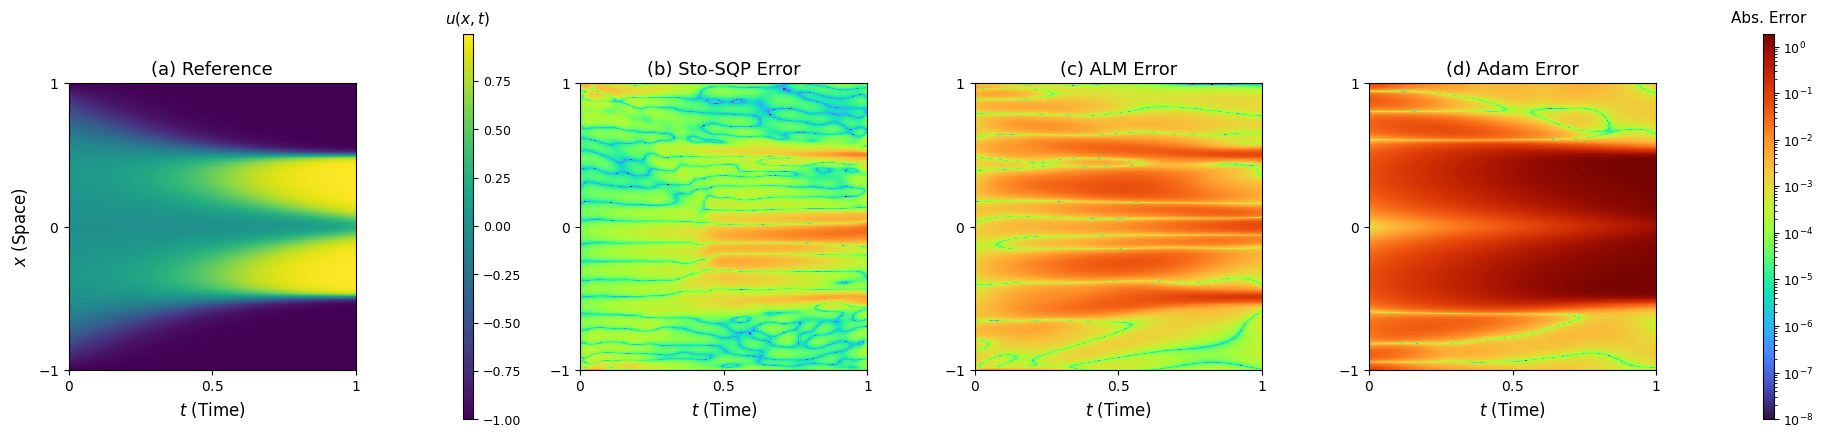

: 

In [ ]:
# ============================================================
# Allen-Cahn heatmaps: Reference + Sto-SQP error + ALM error + Adam error
# NO deterministic SQP heatmap
# ============================================================

import os
from pathlib import Path
import math

import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ============================================================
# User paths
# ============================================================
MAT_PATH = "../1/allen_cahn_python.mat"

# EDIT THESE IF YOUR FILE NAMES ARE DIFFERENT
STO_SQP_PATH = "../1/allen_cahn_stosqp_final_deter.npy"
ALM_PATH     = "../1/traditional_alm_allen_cahn_best.npy"
ADAM_PATH    = "../allen_cahn_adam_best_theta.npy"

SAVE_PREFIX = "allen_cahn_reference_plus_stosqp_alm_adam_errors"

# ============================================================
# Architectures
# ============================================================
SQP_LAYER_SIZES  = [2, 30, 30, 30, 1]          # Sto-SQP and ALM
ALM_LAYER_SIZES  = [2, 30, 30, 30, 1]
ADAM_LAYER_SIZES = [2, 50, 50, 50, 50, 1]      # Adam 50 x 4

# ============================================================
# Domain
# ============================================================
X_MIN, X_MAX = -1.0, 1.0
T_MIN, T_MAX = 0.0, 1.0

# ============================================================
# Plot settings
# ============================================================
REF_CMAP = "viridis"
ERR_CMAP = "turbo"

ERR_FLOOR = 1e-8
ERR_PERCENTILE = 99.5

# ============================================================
# Helpers
# ============================================================
def check_file(path):
    if not Path(path).exists():
        raise FileNotFoundError(f"Missing file: {path}")


def load_reference(mat_path):
    check_file(mat_path)

    data = scipy.io.loadmat(mat_path)
    t = np.asarray(data["t"]).squeeze().astype(np.float64)
    x = np.asarray(data["x"]).squeeze().astype(np.float64)
    usol = np.asarray(data["usol"]).astype(np.float64)

    # If stored as (nx, nt), transpose to (nt, nx)
    if usol.shape == (x.size, t.size):
        usol = usol.T

    if usol.shape != (t.size, x.size):
        raise ValueError(
            f"Unexpected usol shape {usol.shape}. Expected {(t.size, x.size)}."
        )

    return x, t, usol


def make_grid(x, t):
    TT, XX = np.meshgrid(t, x, indexing="ij")
    X_grid = np.stack([XX.reshape(-1), TT.reshape(-1)], axis=1)
    return X_grid


def normalize_xt_np(X):
    x = X[:, 0:1]
    t = X[:, 1:2]

    x_n = 2.0 * (x - X_MIN) / (X_MAX - X_MIN) - 1.0
    t_n = 2.0 * (t - T_MIN) / (T_MAX - T_MIN) - 1.0

    return np.concatenate([x_n, t_n], axis=1)


def unflatten_theta(theta, layer_sizes):
    params = []
    idx = 0

    for m, n in zip(layer_sizes[:-1], layer_sizes[1:]):
        W_size = m * n
        b_size = n

        W = theta[idx:idx + W_size].reshape(m, n)
        idx += W_size

        b = theta[idx:idx + b_size].reshape(1, n)
        idx += b_size

        params.append((W, b))

    if idx != theta.size:
        raise ValueError(
            f"Theta size mismatch. Used {idx} parameters, but theta has {theta.size}."
        )

    return params


def mlp_predict_np(theta, layer_sizes, X):
    params = unflatten_theta(theta, layer_sizes)
    h = normalize_xt_np(X)

    for i, (W, b) in enumerate(params):
        h = h @ W + b
        if i < len(params) - 1:
            h = np.tanh(h)

    return h[:, 0]


def predict_on_grid(theta_path, layer_sizes, x, t):
    check_file(theta_path)
    theta = np.asarray(np.load(theta_path, allow_pickle=True), dtype=np.float64).reshape(-1)

    print(f"{theta_path}: theta size = {theta.size}")

    X_grid = make_grid(x, t)
    u_pred = mlp_predict_np(theta, layer_sizes, X_grid).reshape(t.size, x.size)

    return u_pred


def metrics(u_pred, u_ref):
    mse = float(np.mean((u_pred - u_ref) ** 2))
    rel_l2 = float(np.linalg.norm(u_pred - u_ref) / (np.linalg.norm(u_ref) + 1e-12))
    return mse, rel_l2


# ============================================================
# Main
# ============================================================
def main():
    # --------------------------------------------------------
    # Load reference
    # --------------------------------------------------------
    x, t, u_ref = load_reference(MAT_PATH)

    print("Loaded Allen-Cahn reference")
    print("  x:", x.shape)
    print("  t:", t.shape)
    print("  u_ref:", u_ref.shape)

    # --------------------------------------------------------
    # Predict
    # --------------------------------------------------------
    u_sto = predict_on_grid(STO_SQP_PATH, SQP_LAYER_SIZES, x, t)
    u_alm = predict_on_grid(ALM_PATH, ALM_LAYER_SIZES, x, t)
    u_adam = predict_on_grid(ADAM_PATH, ADAM_LAYER_SIZES, x, t)

    # --------------------------------------------------------
    # Errors
    # --------------------------------------------------------
    err_sto = np.abs(u_sto - u_ref)
    err_alm = np.abs(u_alm - u_ref)
    err_adam = np.abs(u_adam - u_ref)

    # --------------------------------------------------------
    # Print metrics
    # --------------------------------------------------------
    for name, upred in [
        ("Sto-SQP", u_sto),
        ("ALM", u_alm),
        ("Adam", u_adam),
    ]:
        mse, rel_l2 = metrics(upred, u_ref)
        print(f"{name:10s}  MSE = {mse:.6e}   relL2 = {rel_l2:.6e}")

    # --------------------------------------------------------
    # Common color scales
    # --------------------------------------------------------
    ref_vmin = float(np.min(u_ref))
    ref_vmax = float(np.max(u_ref))

    all_err = np.concatenate([
        err_sto.ravel(),
        err_alm.ravel(),
        err_adam.ravel(),
    ])

    err_vmax = float(np.percentile(all_err, ERR_PERCENTILE))
    err_vmax = max(err_vmax, ERR_FLOOR * 10.0)

    err_norm = LogNorm(vmin=ERR_FLOOR, vmax=err_vmax)

    err_sto_plot = np.maximum(err_sto, ERR_FLOOR)
    err_alm_plot = np.maximum(err_alm, ERR_FLOOR)
    err_adam_plot = np.maximum(err_adam, ERR_FLOOR)

    extent = [float(t[0]), float(t[-1]), float(x[0]), float(x[-1])]

    # --------------------------------------------------------
    # Figure layout
    # --------------------------------------------------------
    fig = plt.figure(figsize=(22, 5.0))

    gs = fig.add_gridspec(
        1,
        6,
        width_ratios=[1.0, 0.035, 1.0, 1.0, 1.0, 0.035],
        wspace=0.55,
    )

    ax_ref  = fig.add_subplot(gs[0, 0])
    cax_ref = fig.add_subplot(gs[0, 1])

    ax_sto  = fig.add_subplot(gs[0, 2])
    ax_alm  = fig.add_subplot(gs[0, 3])
    ax_adam = fig.add_subplot(gs[0, 4])

    cax_err = fig.add_subplot(gs[0, 5])

    # --------------------------------------------------------
    # Reference
    # --------------------------------------------------------
    im_ref = ax_ref.imshow(
        u_ref.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=REF_CMAP,
        vmin=ref_vmin,
        vmax=ref_vmax,
        interpolation="nearest",
    )

    cb_ref = fig.colorbar(im_ref, cax=cax_ref)
    cb_ref.ax.set_title(r"$u(x,t)$", fontsize=11, pad=8)
    cb_ref.ax.tick_params(labelsize=9)

    ax_ref.set_title("(a) Reference", fontsize=13)

    # --------------------------------------------------------
    # Errors
    # --------------------------------------------------------
    im_sto = ax_sto.imshow(
        err_sto_plot.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=ERR_CMAP,
        norm=err_norm,
        interpolation="nearest",
    )
    ax_sto.set_title("(b) Sto-SQP Error", fontsize=13)

    im_alm = ax_alm.imshow(
        err_alm_plot.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=ERR_CMAP,
        norm=err_norm,
        interpolation="nearest",
    )
    ax_alm.set_title("(c) ALM Error", fontsize=13)

    im_adam = ax_adam.imshow(
        err_adam_plot.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=ERR_CMAP,
        norm=err_norm,
        interpolation="nearest",
    )
    ax_adam.set_title("(d) Adam Error", fontsize=13)

    cb_err = fig.colorbar(im_adam, cax=cax_err)
    cb_err.ax.set_title("Abs. Error", fontsize=11, pad=8)
    cb_err.ax.tick_params(labelsize=9)

    # --------------------------------------------------------
    # Axis labels / tick labels
    # --------------------------------------------------------
    all_axes = [ax_ref, ax_sto, ax_alm, ax_adam]

    for ax in all_axes:
        ax.set_xlabel(r"$t$ (Time)", fontsize=12)
        ax.set_xlim(float(t[0]), float(t[-1]))
        ax.set_ylim(float(x[0]), float(x[-1]))

        ax.set_xticks([0.0, 0.5, 1.0])
        ax.set_xticklabels([r"$0$", r"$0.5$", r"$1$"])

        ax.set_yticks([-1.0, 0.0, 1.0])
        ax.set_yticklabels([r"$-1$", r"$0$", r"$1$"])

        ax.tick_params(labelsize=10)
        ax.set_box_aspect(1)

    ax_ref.set_ylabel(r"$x$ (Space)", fontsize=12)

    for ax in [ax_sto, ax_alm, ax_adam]:
        ax.set_ylabel("")

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------
    fig.savefig(f"{SAVE_PREFIX}.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(f"{SAVE_PREFIX}.pdf", bbox_inches="tight", pad_inches=0.02)

    print(f"Saved -> {SAVE_PREFIX}.png")
    print(f"Saved -> {SAVE_PREFIX}.pdf")

    plt.show()


if __name__ == "__main__":
    main()